In [46]:
import pandas as pd

# Read dataset
df = pd.read_csv("Data/synthetic_mental_health_dataset.csv")

# Separate variables
X = df.drop("stress_level", axis=1) 
y = df["stress_level"]               

In [47]:
# Fill missing numerical values
df.fillna(df.mean(numeric_only=True), inplace=True)

# Fill missing categorical values (fixed version)
for col in df.select_dtypes(include='object'):
    df[col] = df[col].fillna(df[col].mode()[0])

# Remove duplicates
df.drop_duplicates(inplace=True)

In [48]:
# Convert categorical variables to numeric
df = pd.get_dummies(df, drop_first=True)

In [49]:
from sklearn.model_selection import train_test_split

X = df.drop("stress_level", axis=1)
y = df["stress_level"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
# Read dataset
df = pd.read_csv("Data/synthetic_mental_health_dataset.csv")
df.head()

,sleep_hours,screen_time,exercise_minutes,daily_pending_tasks,interruptions,fatigue_level,social_hours,coffee_cups,diet_quality,weather,mood_score,stress_level
0,7.745071,3.649643,13.272466,1,5,4.179955,2.448854,1,average,snowy,9.171062,1.000000
1,6.792604,4.710963,1.785436,3,6,4.883679,1.330623,3,good,sunny,5.706491,3.558516
2,7.971533,3.415160,71.843325,4,10,4.207812,2.134120,0,poor,cloudy,10.000000,2.971450
3,9.284545,4.384077,14.596656,2,4,3.362592,1.857070,0,good,sunny,8.385038,1.000000
4,6.648770,1.212771,19.048010,3,5,6.229107,2.642980,1,poor,rainy,10.000000,1.639047


In [8]:
df.isnull().sum()

sleep_hours            0
screen_time            0
exercise_minutes       0
daily_pending_tasks    0
interruptions          0
fatigue_level          0
social_hours           0
coffee_cups            0
diet_quality           0
weather                0
mood_score             0
stress_level           0
dtype: int64

In [9]:
df["Total_stress"] = (
    0.2 * df["sleep_hours"] +
    0.2 * df["screen_time"] +
    0.2 * df["fatigue_level"] +
    0.2 * df["interruptions"] +
    0.2 * df["daily_pending_tasks"]
)

df.head()

,sleep_hours,screen_time,exercise_minutes,daily_pending_tasks,interruptions,fatigue_level,social_hours,coffee_cups,diet_quality,weather,mood_score,stress_level,Total_stress
0,7.745071,3.649643,13.272466,1,5,4.179955,2.448854,1,average,snowy,9.171062,1.000000,4.314934
1,6.792604,4.710963,1.785436,3,6,4.883679,1.330623,3,good,sunny,5.706491,3.558516,5.077449
2,7.971533,3.415160,71.843325,4,10,4.207812,2.134120,0,poor,cloudy,10.000000,2.971450,5.918901
3,9.284545,4.384077,14.596656,2,4,3.362592,1.857070,0,good,sunny,8.385038,1.000000,4.606243
4,6.648770,1.212771,19.048010,3,5,6.229107,2.642980,1,poor,rainy,10.000000,1.639047,4.418129


In [10]:
import numpy as np

# اختيار الأعمدة الرقمية فقط
numeric_df = df.select_dtypes(include=[np.number])

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

df_clean = df[~((numeric_df < (Q1 - 1.5 * IQR)) | 
                 (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)]

df_clean.head()

,sleep_hours,screen_time,exercise_minutes,daily_pending_tasks,interruptions,fatigue_level,social_hours,coffee_cups,diet_quality,weather,mood_score,stress_level,Total_stress
0,7.745071,3.649643,13.272466,1,5,4.179955,2.448854,1,average,snowy,9.171062,1.000000,4.314934
1,6.792604,4.710963,1.785436,3,6,4.883679,1.330623,3,good,sunny,5.706491,3.558516,5.077449
3,9.284545,4.384077,14.596656,2,4,3.362592,1.857070,0,good,sunny,8.385038,1.000000,4.606243
4,6.648770,1.212771,19.048010,3,5,6.229107,2.642980,1,poor,rainy,10.000000,1.639047,4.418129
5,6.648795,5.426587,5.399719,3,3,4.702907,2.141541,0,poor,cloudy,5.916326,1.032066,4.555658


In [11]:
from sklearn.model_selection import train_test_split

X = df[[
    "sleep_hours",
    "screen_time",
    "fatigue_level",
    "interruptions",
    "daily_pending_tasks"
]]

y = df["Total_stress"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1600, 5)
(400, 5)


In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

print("Linear Regression")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2:", r2_score(y_test, y_pred_lr))

Linear Regression
MSE: 2.4489200726454786e-30
R2: 1.0


In [13]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

y_pred_poly = model_poly.predict(X_test_poly)

print("Polynomial Regression")
print("MSE:", mean_squared_error(y_test, y_pred_poly))
print("R2:", r2_score(y_test, y_pred_poly))

Polynomial Regression
MSE: 3.8069934247900265e-29
R2: 1.0


In [14]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

model_ridge = Ridge()
model_ridge.fit(X_train, y_train)

y_pred_ridge = model_ridge.predict(X_test)

print("Ridge Regression")
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("R2:", r2_score(y_test, y_pred_ridge))

Ridge Regression
MSE: 2.4212008343148268e-08
R2: 0.9999999656177418


In [15]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score

model_lasso = Lasso()
model_lasso.fit(X_train, y_train)

y_pred_lasso = model_lasso.predict(X_test)

print("Lasso Regression")
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("R2:", r2_score(y_test, y_pred_lasso))

Lasso Regression
MSE: 0.6975719661185468
R2: 0.00941305447053098


In [16]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

model_en = ElasticNet()
model_en.fit(X_train, y_train)

y_pred_en = model_en.predict(X_test)

print("Elastic Net Regression")
print("MSE:", mean_squared_error(y_test, y_pred_en))
print("R2:", r2_score(y_test, y_pred_en))

Elastic Net Regression
MSE: 0.3906601212181143
R2: 0.44524316484378434


In [17]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Linear", "Polynomial", "Ridge", "Lasso", "Elastic Net"],
    "MSE": [
        mean_squared_error(y_test, y_pred_lr),
        mean_squared_error(y_test, y_pred_poly),
        mean_squared_error(y_test, y_pred_ridge),
        mean_squared_error(y_test, y_pred_lasso),
        mean_squared_error(y_test, y_pred_en)
    ],
    "R2": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_poly),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso),
        r2_score(y_test, y_pred_en)
    ]
})

print(results)

         Model           MSE        R2
0       Linear  2.448920e-30  1.000000
1   Polynomial  3.806993e-29  1.000000
2        Ridge  2.421201e-08  1.000000
3        Lasso  6.975720e-01  0.009413
4  Elastic Net  3.906601e-01  0.445243


In [18]:
print("Intercept:", model_lr.intercept_)
print("Coefficients:", model_lr.coef_)

Intercept: 0.0
Coefficients: [0.2 0.2 0.2 0.2 0.2]


In [19]:
print("Intercept:", model_poly.intercept_)
print("Coefficients:", model_poly.coef_)

Intercept: 1.4210854715202004e-14
Coefficients: [ 0.00000000e+00  2.00000000e-01  2.00000000e-01  2.00000000e-01
  2.00000000e-01  2.00000000e-01  1.98090013e-17  2.95296080e-16
 -6.52469910e-17  2.38063150e-17  2.75495957e-17 -1.33688449e-16
  9.13433728e-17 -1.07183566e-16 -1.20336329e-16  2.26819643e-17
 -7.75009917e-17  3.13008082e-17  1.45594096e-16 -3.97717476e-17
 -6.25333529e-17]


In [20]:
plt.scatter(y_test, y_pred_lr)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Observed vs Predicted")

plt.show()

NameError: name 'plt' is not defined

In [61]:
# 1) Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [62]:
# 3) Create classification target

# We convert the numeric stress_level into categories:
# Low    -> stress_level < 2
# Medium -> 2 <= stress_level < 4
# High   -> stress_level >= 4

df["Stress_Category"] = pd.cut(
    df["stress_level"],
    bins=[-np.inf, 2, 4, np.inf],
    labels=["Low", "Medium", "High"],
    right=False
)

print("\nTarget categories count:")
print(df["Stress_Category"].value_counts())




Target categories count:
Stress_Category
Low       1206
Medium     552
High       242
Name: count, dtype: int64


In [63]:
# 4) Define X and y

# Remove the original numeric target and the new class target from X
X = df.drop(columns=["stress_level", "Stress_Category"])
y = df["Stress_Category"]

# Separate numeric and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("\nNumeric features:")
print(list(numeric_features))

print("\nCategorical features:")
print(list(categorical_features))


Numeric features:
['sleep_hours', 'screen_time', 'exercise_minutes', 'daily_pending_tasks', 'interruptions', 'fatigue_level', 'social_hours', 'coffee_cups', 'mood_score']

Categorical features:
[]


In [64]:
# 5) Preprocessing

# Numeric data:
# - fill missing values with median
# - scale values
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical data:
# - fill missing values with most frequent value
# - convert text categories to numbers using OneHotEncoder
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Apply both transformations
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [65]:
# 6) Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])



Training set size: 1600
Testing set size: 400


In [66]:
# 7) Build classification models

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel="rbf"),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, max_depth=8)
}

results = []
trained_pipelines = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    
    results.append([name, acc, prec, rec, f1])
    trained_pipelines[name] = pipeline

    # Create comparison table
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])
results_df = results_df.sort_values(by="F1 Score", ascending=False)

print("\nClassification Results:")
print(results_df)



Classification Results:
                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression    0.9025   0.903079  0.9025  0.902643
2                  SVM    0.8975   0.898244  0.8975  0.896693
4        Random Forest    0.8675   0.866017  0.8675  0.866171
3        Decision Tree    0.8350   0.838463  0.8350  0.834620
1                  KNN    0.8100   0.805078  0.8100  0.803908


In [67]:
# 8) Best classifier

best_model_name = results_df.iloc[0]["Model"]
best_model = trained_pipelines[best_model_name]

print("\nBest Classifier:", best_model_name)

# Predict again using best model
best_pred = best_model.predict(X_test)

print("\nClassification Report for Best Model:")
print(classification_report(y_test, best_pred))




Best Classifier: Logistic Regression

Classification Report for Best Model:
              precision    recall  f1-score   support

        High       0.89      0.84      0.86        49
         Low       0.95      0.95      0.95       241
      Medium       0.81      0.84      0.83       110

    accuracy                           0.90       400
   macro avg       0.88      0.87      0.88       400
weighted avg       0.90      0.90      0.90       400



In [68]:
# 9) Number of elements in each category

print("\nNumber of elements in each target category:")
print(df["Stress_Category"].value_counts())



Number of elements in each target category:
Stress_Category
Low       1206
Medium     552
High       242
Name: count, dtype: int64


In [69]:
# 10) Cluster Analysis

# We use selected features for clustering
cluster_features = ["sleep_hours", "screen_time", "fatigue_level", "interruptions", "daily_pending_tasks"]

cluster_data = df[cluster_features]

# Scale the clustering data
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_data)


In [70]:
# 11) Find optimal number of clusters

inertia_values = []
silhouette_values = []
k_values = range(2, 7)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(cluster_scaled)
    
    inertia_values.append(kmeans.inertia_)
    silhouette_values.append(silhouette_score(cluster_scaled, labels))

# Print values
print("\nElbow and Silhouette Results:")
for k, inertia, sil in zip(k_values, inertia_values, silhouette_values):
    print(f"k = {k}, Inertia = {inertia:.2f}, Silhouette Score = {sil:.4f}")



Elbow and Silhouette Results:
k = 2, Inertia = 8647.76, Silhouette Score = 0.1340
k = 3, Inertia = 7670.82, Silhouette Score = 0.1329
k = 4, Inertia = 6898.85, Silhouette Score = 0.1368
k = 5, Inertia = 6311.62, Silhouette Score = 0.1399
k = 6, Inertia = 5829.73, Silhouette Score = 0.1426


In [71]:
# 12) Apply KMeans with chosen k

# We choose k=3 for simple interpretation
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans_final.fit_predict(cluster_scaled)

print("\nCluster counts:")
print(df["Cluster"].value_counts())



Cluster counts:
Cluster
1    729
0    710
2    561
Name: count, dtype: int64


In [72]:
# 13) Cluster profile

cluster_profile = df.groupby("Cluster")[cluster_features + ["stress_level"]].mean()
print("\nCluster Profile (Average Values):")
print(cluster_profile)



Cluster Profile (Average Values):
         sleep_hours  screen_time  fatigue_level  interruptions  \
Cluster                                                           
0           7.164174     3.835902       6.336901       4.456338   
1           7.191770     5.971414       3.547993       5.604938   
2           6.782726     5.175342       5.183336       5.368984   

         daily_pending_tasks  stress_level  
Cluster                                     
0                   2.166197      1.467525  
1                   2.149520      1.470988  
2                   4.976827      3.823531  


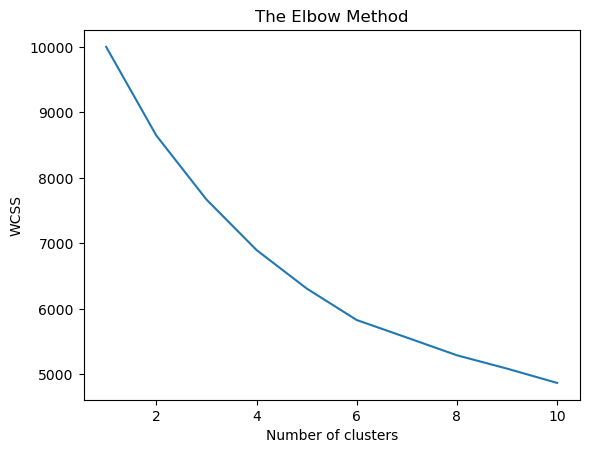

In [73]:

# 14) Plot Elbow Method

# Create an empty list to store WCSS values
wcss = []

# Loop over different numbers of clusters (from 1 to 10)
for i in range(1, 11):
    
    # Initialize KMeans with k clusters
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    
    # Fit the model to the scaled cluster data
    kmeans.fit(cluster_scaled)
    
    # Append the WCSS (inertia) value to the list
    wcss.append(kmeans.inertia_)

# Plot the Elbow graph
plt.plot(range(1, 11), wcss)

# Add title and labels
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')

# Display the plot
plt.show()


In [74]:
# Apply KMeans clustering and assign each data point to a cluster
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(cluster_scaled)

# Print cluster labels
print(y_kmeans)

[0 1 2 ... 2 1 0]


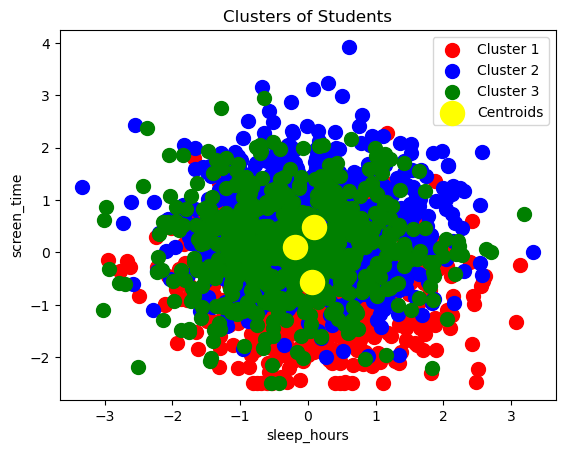

In [75]:

# 15) Plot clustered data

# Convert the scaled clustering data into a variable
X_cluster = cluster_scaled

# Plot Cluster 1 (points where y_kmeans == 0)
plt.scatter(X_cluster[y_kmeans == 0, 0], X_cluster[y_kmeans == 0, 1],
            s=100, c='red', label='Cluster 1')

# Plot Cluster 2
plt.scatter(X_cluster[y_kmeans == 1, 0], X_cluster[y_kmeans == 1, 1],
            s=100, c='blue', label='Cluster 2')

# Plot Cluster 3
plt.scatter(X_cluster[y_kmeans == 2, 0], X_cluster[y_kmeans == 2, 1],
            s=100, c='green', label='Cluster 3')

# If using 4 clusters, uncomment this line
# plt.scatter(X_cluster[y_kmeans == 3, 0], X_cluster[y_kmeans == 3, 1],
#             s=100, c='cyan', label='Cluster 4')

# Plot the centroids (center of each cluster)
plt.scatter(kmeans_final.cluster_centers_[:, 0],
            kmeans_final.cluster_centers_[:, 1],
            s=300, c='yellow', label='Centroids')

# Add title and axis labels
plt.title('Clusters of Students')
plt.xlabel('sleep_hours')
plt.ylabel('screen_time')

# Show legend
plt.legend()

# Display the plot
plt.show()

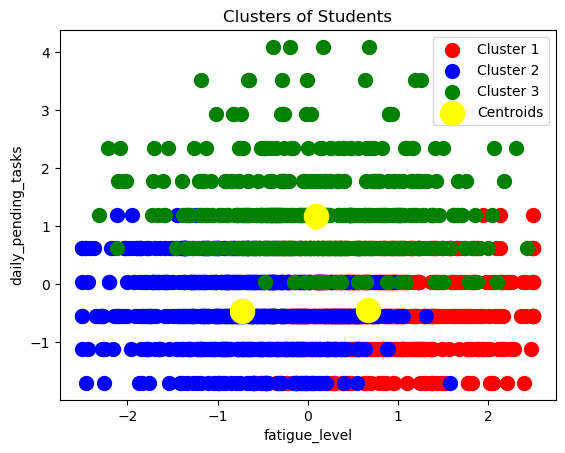

In [76]:

# 15) Visualizing Clusters (New Axes)


# Convert scaled data to variable
X_cluster = cluster_scaled

# Plot Cluster 1
plt.scatter(X_cluster[y_kmeans == 0, 2], X_cluster[y_kmeans == 0, 4],
            s=100, c='red', label='Cluster 1')

# Plot Cluster 2
plt.scatter(X_cluster[y_kmeans == 1, 2], X_cluster[y_kmeans == 1, 4],
            s=100, c='blue', label='Cluster 2')

# Plot Cluster 3
plt.scatter(X_cluster[y_kmeans == 2, 2], X_cluster[y_kmeans == 2, 4],
            s=100, c='green', label='Cluster 3')

# If using 4 clusters
# plt.scatter(X_cluster[y_kmeans == 3, 2], X_cluster[y_kmeans == 3, 4],
#             s=100, c='cyan', label='Cluster 4')

# Plot centroids
plt.scatter(kmeans_final.cluster_centers_[:, 2],
            kmeans_final.cluster_centers_[:, 4],
            s=300, c='yellow', label='Centroids')

# Labels
plt.title('Clusters of Students')
plt.xlabel('fatigue_level')
plt.ylabel('daily_pending_tasks')

plt.legend()
plt.show()

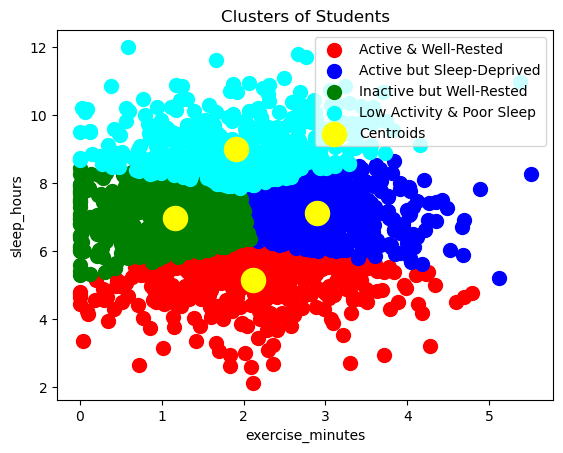

In [77]:

# 15) Visualizing Clusters 


# Select the correct columns
# exercise_minutes = column 6
# sleep_hours = column 0

X = df.iloc[:, [6, 0]].values

# Apply KMeans
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X)

plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1],
            s=100, c='red', label='Active & Well-Rested')

plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1],
            s=100, c='blue', label='Active but Sleep-Deprived')

plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1],
            s=100, c='green', label='Inactive but Well-Rested')

plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1],
            s=100, c='cyan', label='Low Activity & Poor Sleep')

# Plot centroids
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=300, c='yellow', label='Centroids')

# Titles and labels
plt.title('Clusters of Students')
plt.xlabel('exercise_minutes')
plt.ylabel('sleep_hours')

plt.legend()
plt.show()